In [151]:
!pip install --upgrade seaborn
!pip install plotly

In [152]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns

## Inspect and clean dataset

In [153]:
#trip_data = pd.read_csv('./Data_saved/Only_trip/Vehicle2_clean_data_400epochs/Generated_data/EV_generated_data.csv')

trip_data = pd.read_csv('./Generated_data/EV_generated_data.csv')

In [154]:
# Remove duplicates
trip_data = trip_data.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data)}")

trip_data['km_driven'] = trip_data['end_odo'] - trip_data['odo']
trip_data['discharge'] = trip_data['soc'] - trip_data['end_soc']

print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())

Number of rows after removing duplicates: 12096
📊 Statistics on driven km:
 count    12096.000000
mean       127.018260
std        132.886778
min       -673.394964
25%         47.908091
50%        139.371651
75%        214.667806
max        701.129152
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    12096.000000
mean         7.652329
std          5.155843
min         -0.968307
25%          4.315816
50%          6.026034
75%          9.139800
max         35.819583
Name: discharge, dtype: float64


In [155]:
nan_count = trip_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

print("\n🔍 Rows with missing values:\n")

rows_with_nan = trip_data[trip_data.isna().any(axis=1)]

rows_with_nan.head(len(rows_with_nan))

| Features | NaN-counter |
odo                 0
end_odo             0
soc                 0
end_soc             0
event               0
charge_mode         0
duration_minutes    0
km_driven           0
discharge           0
dtype: int64
|----------|-------------|

🔍 Rows with missing values:



,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge


In [156]:
useless_rows_trip = trip_data[(trip_data['soc'] == trip_data['end_soc']) & (trip_data['end_odo'] == trip_data['odo']) & (trip_data['duration_minutes'] == 0)]
print(f"Number of useless rows: {useless_rows_trip.shape[0]}")
useless_rows_trip.head(len(useless_rows_trip))

Number of useless rows: 0


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge


In [157]:
trip_data = trip_data.drop(useless_rows_trip.index)
trip_data = trip_data.reset_index(drop=True)

In [158]:
# add a column avg_speed in km/h for trip
trip_data['avg_speed'] = np.where(
    trip_data['duration_minutes'] > 0,
    (trip_data['end_odo'] - trip_data['odo']) / (trip_data['duration_minutes'] / 60),
    0
)

In [159]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12096 entries, 0 to 12095
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   odo               12096 non-null  float64
 1   end_odo           12096 non-null  float64
 2   soc               12096 non-null  float64
 3   end_soc           12096 non-null  float64
 4   event             12096 non-null  float64
 5   charge_mode       12096 non-null  float64
 6   duration_minutes  12096 non-null  float64
 7   km_driven         12096 non-null  float64
 8   discharge         12096 non-null  float64
 9   avg_speed         12096 non-null  float64
dtypes: float64(10)
memory usage: 945.1 KB


In [160]:
# statistics of the dataset for odo, end_odo, soc, end_soc
print("Statistics of the dataset:")
trip_data[['odo', 'end_odo', 'soc', 'end_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
odo,12096.0,11201.415902,1299.494912,6454.775843,10339.315024,11228.197983,12077.812440,16065.715255
end_odo,12096.0,11328.434162,1308.395993,6428.293617,10456.275783,11360.087771,12209.847207,16173.032056
soc,12096.0,62.605505,9.385226,26.284194,56.140954,63.016399,69.567870,87.482534
end_soc,12096.0,54.953176,10.590837,16.067836,48.661456,55.657268,62.283979,84.072095


In [161]:
anomalous_rows_time = trip_data[(trip_data['duration_minutes'] < 0)]
print(f"Number of anomalous rows: {anomalous_rows_time.shape[0]}")
print("Anomalous rows:")
print(anomalous_rows_time.head(len(anomalous_rows_time)))

trip_data = trip_data[~(trip_data['duration_minutes'] < 0)].reset_index(drop=True)

Number of anomalous rows: 0
Anomalous rows:
Empty DataFrame
Columns: [odo, end_odo, soc, end_soc, event, charge_mode, duration_minutes, km_driven, discharge, avg_speed]
Index: []


In [162]:
useless_rows_trip = trip_data[ (trip_data['soc'] == trip_data['end_soc']) & (trip_data['end_odo'] == trip_data['odo']) & (trip_data['duration_minutes'] > 0)]
print(f"Number of anomalous rows: {useless_rows_trip.shape[0]}")

Number of anomalous rows: 0


In [163]:
anomalous_rows_trip = trip_data[(trip_data['end_soc'] == trip_data['soc']) & (trip_data['end_odo'] > trip_data['odo']) & (trip_data['duration_minutes'] > 0)].copy()
anomalous_rows_trip['km_driven']=anomalous_rows_trip['end_odo'] - anomalous_rows_trip['odo']
anomalous_rows_trip = anomalous_rows_trip.sort_values(by='duration_minutes', ascending=False)

print(f"Number of anomalous rows: {anomalous_rows_trip.shape[0]}")
anomalous_rows_trip.head(len(anomalous_rows_trip))

Number of anomalous rows: 0


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed


In [164]:
anomalous_rows_trip = trip_data[(trip_data['end_soc'] > trip_data['soc'])].copy()
anomalous_rows_trip['km_driven'] = anomalous_rows_trip['end_odo'] - anomalous_rows_trip['odo']
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 4


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed
2758,12644.062917,12639.929289,44.134007,44.218260,2.564786e-10,1.770286e-10,29.279270,-4.133627,-0.084253,-8.470759
4271,14139.203689,14247.177728,52.050761,52.667394,4.305306e-10,3.409289e-10,29.605627,107.974039,-0.616633,218.824700
5975,11278.938549,11223.651807,34.949408,35.764432,5.160257e-10,3.398789e-10,26.352447,-55.286742,-0.815024,-125.878426
6287,12871.916154,12874.435611,41.171210,42.139517,4.567471e-10,3.282075e-10,27.129565,2.519457,-0.968307,5.572055


In [165]:
#if it increase more than 1% delete the row from data 
inital_length = len(trip_data)
element = trip_data[((trip_data['end_soc'] - trip_data['soc']) > 1)]
print(f"Number of rows removed: {element}")
trip_data = trip_data[~(((trip_data['end_soc'] - trip_data['soc']) > 1))].reset_index(drop=True)
print(f"Element removed from the dataset where event = 'trip' and end_soc - soc > 1%")

final_length = len(trip_data)
print(f"Number of rows removed: {inital_length - final_length}")

Number of rows removed: Empty DataFrame
Columns: [odo, end_odo, soc, end_soc, event, charge_mode, duration_minutes, km_driven, discharge, avg_speed]
Index: []
Element removed from the dataset where event = 'trip' and end_soc - soc > 1%
Number of rows removed: 0


In [166]:
anomalous_rows_trip = trip_data[(trip_data['end_odo'] < trip_data['odo'])]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data = trip_data[~(trip_data['end_odo'] < trip_data['odo'])].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 1927


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed
0,11849.024187,11767.026719,56.582170,49.002914,3.505673e-10,2.993936e-10,47.322888,-81.997469,7.579256,-103.963394
12,12571.121046,12533.831134,49.293597,43.763566,2.214604e-10,1.598180e-10,51.491394,-37.289911,5.530031,-43.451818
13,12549.753342,12488.398616,48.148067,44.018738,2.183876e-10,1.542694e-10,44.279918,-61.354725,4.129328,-83.136638
15,12409.294154,12403.164484,53.162258,30.123313,3.034156e-10,3.364842e-10,158.620892,-6.129670,23.038944,-2.318611
16,12753.278878,12668.035898,46.241693,44.111399,2.267490e-10,1.544976e-10,37.237477,-85.242980,2.130294,-137.350306
...,...,...,...,...,...,...,...,...,...,...
12046,12692.232855,12333.641253,85.189286,79.423535,2.335557e-10,2.337924e-10,38.264528,-358.591602,5.765751,-562.283068
12047,12454.320551,12147.416839,81.980199,65.583425,4.175079e-10,4.705911e-10,120.228750,-306.903712,16.396774,-153.159895
12048,10363.018107,10342.193749,66.378454,57.085013,3.132466e-10,2.924901e-10,59.882985,-20.824358,9.293441,-20.865050
12071,11086.705024,10586.712858,83.537130,78.348009,3.785634e-10,3.910927e-10,40.669846,-499.992166,5.189121,-737.635682


In [167]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10169 entries, 0 to 10168
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   odo               10169 non-null  float64
 1   end_odo           10169 non-null  float64
 2   soc               10169 non-null  float64
 3   end_soc           10169 non-null  float64
 4   event             10169 non-null  float64
 5   charge_mode       10169 non-null  float64
 6   duration_minutes  10169 non-null  float64
 7   km_driven         10169 non-null  float64
 8   discharge         10169 non-null  float64
 9   avg_speed         10169 non-null  float64
dtypes: float64(10)
memory usage: 794.6 KB


In [168]:
speed_trip = trip_data.copy()
print("📊 Statistics on driven km:\n", speed_trip['avg_speed'].describe())
p99_speed = speed_trip['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")

📊 Statistics on driven km:
 count    10169.000000
mean       211.569987
std        147.292255
min          0.019398
25%         91.650865
50%        192.145898
75%        305.859596
max        962.018113
Name: avg_speed, dtype: float64
99th percentile of average speed: 635.63 km/h


In [169]:
print("maximum speed: ", trip_data['avg_speed'].max())
max_speed_row = trip_data[(trip_data['avg_speed'] > 130)]

print("\n Row with maximum speed:\n")
max_speed_row.head(len(max_speed_row))

maximum speed:  962.0181134096844

 Row with maximum speed:



,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed
0,11575.677711,11697.086925,52.854833,48.704371,2.324014e-10,1.722743e-10,39.642222,121.409215,4.150462,183.757433
1,11550.330537,11710.969213,53.927295,50.667880,2.149422e-10,1.543893e-10,35.534942,160.638676,3.259415,271.235016
2,11463.133333,11704.263633,58.997051,55.020048,1.987627e-10,1.470964e-10,35.871093,241.130300,3.977003,403.328056
3,11467.880899,11740.083289,65.954373,61.345660,1.813121e-10,1.413307e-10,37.456205,272.202390,4.608713,436.033056
4,11457.064375,11741.498667,67.392057,60.399032,1.818907e-10,1.449922e-10,48.508054,284.434292,6.993025,351.819054
...,...,...,...,...,...,...,...,...,...,...
10162,13386.143577,13588.445811,69.258804,63.437550,1.814183e-10,1.523643e-10,45.925125,202.302234,5.821254,264.302687
10163,13343.192703,13601.002554,64.160771,57.444255,1.877986e-10,1.547448e-10,52.071572,257.809851,6.716516,297.064033
10164,13541.527771,13779.124641,65.397633,61.361520,1.809286e-10,1.479974e-10,40.900240,237.596871,4.036113,348.550819
10167,14025.058612,14172.683704,52.580263,48.683930,2.269003e-10,1.764681e-10,45.562717,147.625092,3.896333,194.402488


In [170]:
trip_data = trip_data.drop(max_speed_row.index).reset_index(drop=True)

In [171]:
trip_data['km_per_perc_of_battery'] = trip_data.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data['discharge_per_km'] = trip_data.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

In [172]:
MAX_DISCHARGE_PER_KM = 26
##########################################################



anomalous_rows_trip = trip_data[(trip_data['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data = trip_data[~(trip_data['discharge_per_km'] > 26)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 9


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
575,12916.074037,12916.523657,47.239604,24.921657,3.510965e-10,3.818109e-10,161.515337,0.449620,22.317947,0.167026,0.020146,49.637321
704,13097.614732,13097.740679,48.066301,44.536724,2.163361e-10,1.538026e-10,42.520219,0.125947,3.529577,0.177723,0.035683,28.024231
893,11199.872524,11199.958358,51.563287,46.146330,2.168376e-10,1.560813e-10,52.712267,0.085833,5.416956,0.097700,0.015845,63.110093
954,11671.031365,11671.565529,60.550426,37.648605,2.643850e-10,2.908836e-10,151.080149,0.534164,22.901822,0.212138,0.023324,42.874135
959,10377.518831,10378.119209,48.920562,23.801428,3.766645e-10,4.591385e-10,190.759194,0.600377,25.119134,0.188838,0.023901,41.838903
1799,12819.859849,12820.091599,52.826028,46.345567,2.173648e-10,1.632004e-10,54.681788,0.231750,6.480461,0.254289,0.035761,27.963189
1958,11588.690124,11588.914612,50.903807,40.565376,2.533883e-10,2.051586e-10,75.312826,0.224488,10.338431,0.178844,0.021714,46.053448
2685,13389.257193,13389.269386,48.378980,46.820905,2.130418e-10,1.543371e-10,37.713564,0.012193,1.558075,0.019398,0.007826,127.784855
2928,13736.593609,13736.639331,51.147104,46.668835,2.122747e-10,1.521674e-10,47.318530,0.045722,4.478268,0.057976,0.010210,97.944824


## Trip Analysis

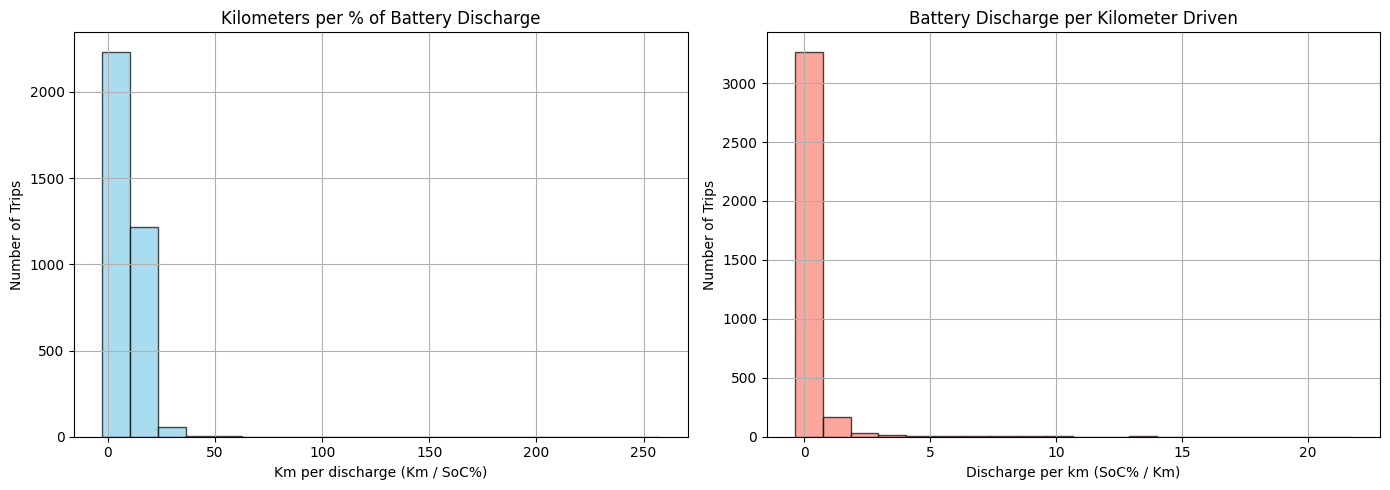

In [173]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kilometers per % battery
axes[0].hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Kilometers per % of Battery Discharge')
axes[0].set_xlabel('Km per discharge (Km / SoC%)')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    trip_data['discharge_per_km'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery Discharge per Kilometer Driven')
axes[1].set_xlabel('Discharge per km (SoC% / Km)')
axes[1].set_ylabel('Number of Trips')
axes[1].grid(True)

plt.tight_layout()
plt.show()

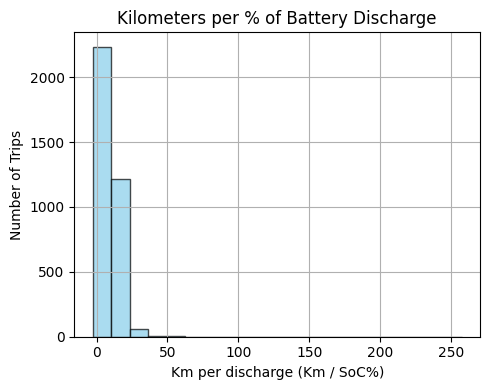

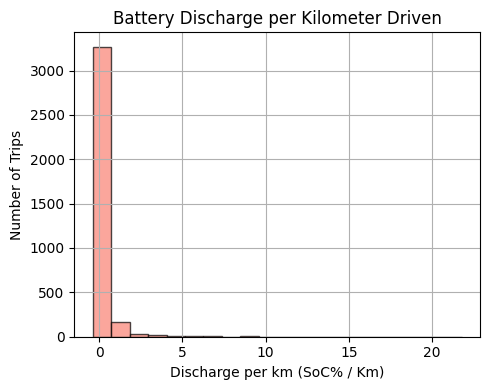

In [174]:
# Number of plots
n_models = 1  # only one dataset
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), squeeze=False)

# First histogram
ax = axes[0, 0]
ax.hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)
ax.set_title('Kilometers per % of Battery Discharge')
ax.set_xlabel('Km per discharge (Km / SoC%)')
ax.set_ylabel('Number of Trips')
ax.grid(True)

plt.tight_layout()
plt.show()

# Second histogram
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), squeeze=False)

ax = axes[0, 0]
ax.hist(
    trip_data['discharge_per_km'],
    bins=20,
    color='salmon',
    edgecolor='black',
    alpha=0.7
)
ax.set_title('Battery Discharge per Kilometer Driven')
ax.set_xlabel('Discharge per km (SoC% / Km)')
ax.set_ylabel('Number of Trips')
ax.grid(True)

plt.tight_layout()
plt.show()


In [175]:
max_km = trip_data['km_per_perc_of_battery'].max()
max_km_row = trip_data[trip_data['km_per_perc_of_battery'] == max_km]

print("\n Row with maximum Km/SoC driven:\n")
max_km_row.head()


 Row with maximum Km/SoC driven:



,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
1816,12220.323874,12276.75994,46.783207,46.564042,3.746022e-10,2.721122e-10,32.674294,56.436066,0.219165,103.633883,257.505093,0.003883


In [176]:
outliers = trip_data[trip_data['km_per_perc_of_battery'] > 20].sort_values(by='km_per_perc_of_battery', ascending=False)
trip_data = trip_data[~(trip_data['km_per_perc_of_battery'] > 20)].reset_index(drop=True)
print(f'There are {len(outliers)} outliers')
outliers.head(len(outliers))

There are 138 outliers


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
1816,12220.323874,12276.759940,46.783207,46.564042,3.746022e-10,2.721122e-10,32.674294,56.436066,0.219165,103.633883,257.505093,0.003883
2866,10347.533155,10355.819844,50.424362,50.336316,3.885213e-10,2.865475e-10,30.794449,8.286690,0.088047,16.145812,94.117143,0.010625
3310,12768.005044,12842.091518,49.072877,48.000533,3.437080e-10,2.631216e-10,36.186474,74.086474,1.072344,122.841158,69.088334,0.014474
640,12403.720636,12473.519508,60.381403,59.199985,3.827377e-10,3.202371e-10,34.862767,69.798873,1.181418,120.126220,59.080591,0.016926
2499,11104.205647,11174.850196,32.892771,31.560070,5.553008e-10,3.656136e-10,33.662044,70.644549,1.332700,125.918466,53.008572,0.018865
...,...,...,...,...,...,...,...,...,...,...,...,...
568,13365.679633,13460.899381,55.680305,50.931251,1.957251e-10,1.471878e-10,47.190388,95.219749,4.749055,121.066708,20.050254,0.049875
1431,11107.025325,11167.680143,51.531679,48.506463,2.045261e-10,1.511179e-10,41.221426,60.654818,3.025216,88.286347,20.049747,0.049876
904,11674.464854,11756.435668,58.508242,54.419462,1.842428e-10,1.412430e-10,41.600763,81.970814,4.088780,118.224966,20.047743,0.049881
2085,10211.982467,10294.924633,54.610842,50.468369,2.039789e-10,1.477209e-10,43.676258,82.942165,4.142473,113.941306,20.022379,0.049944


In [177]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3381 entries, 0 to 3380
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   odo                     3381 non-null   float64
 1   end_odo                 3381 non-null   float64
 2   soc                     3381 non-null   float64
 3   end_soc                 3381 non-null   float64
 4   event                   3381 non-null   float64
 5   charge_mode             3381 non-null   float64
 6   duration_minutes        3381 non-null   float64
 7   km_driven               3381 non-null   float64
 8   discharge               3381 non-null   float64
 9   avg_speed               3381 non-null   float64
 10  km_per_perc_of_battery  3381 non-null   float64
 11  discharge_per_km        3381 non-null   float64
dtypes: float64(12)
memory usage: 317.1 KB


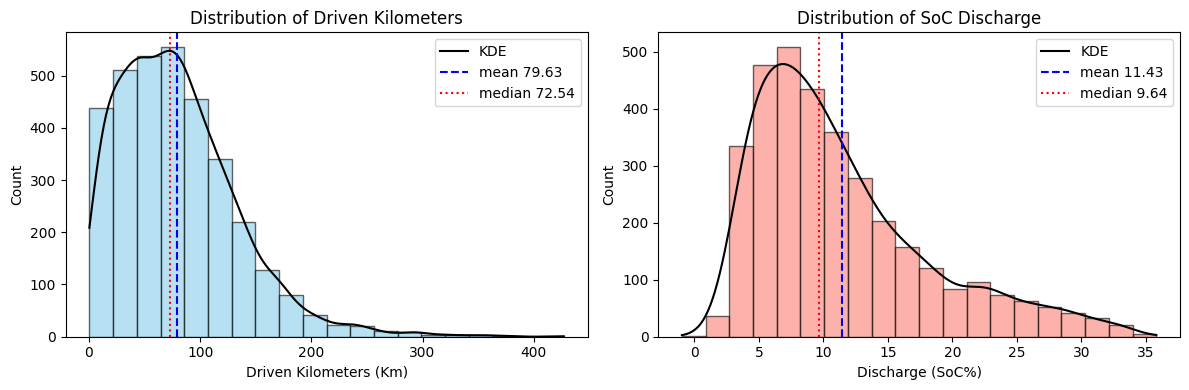

In [178]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20):
    # Ensure numeric and drop NaNs / infs
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_title(title)
        return

    # Histogram (counts)
    counts, bin_edges, _ = ax.hist(y, bins=bins, density=False,
                                   alpha=0.6, color=color, edgecolor='black')

    # KDE scaled to match histogram counts
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        # scale KDE to counts
        kde_vals = kde(x_grid) * len(y) * (bin_edges[1] - bin_edges[0])
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass  # skip KDE if SciPy not available

    # Mean & median vertical lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()

# Usage example
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_hist_with_kde(trip_data.get('km_driven', pd.Series(dtype=float)), axes[0],
                   color='skyblue', title='Distribution of Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data.get('discharge', pd.Series(dtype=float)), axes[1],
                   color='salmon', title='Distribution of SoC Discharge', xlabel='Discharge (SoC%)')

plt.tight_layout()
plt.show()

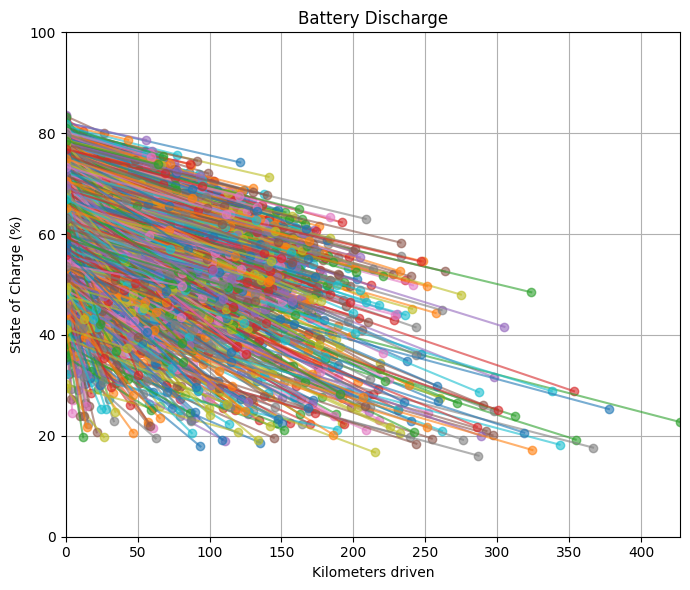

In [180]:
# Max km for x-axis scaling
max_km_driven = trip_data['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


In [181]:
trip_data['discharge_per_km'].describe()

count    3381.000000
mean        0.330256
std         0.967234
min        -0.384332
25%         0.083660
50%         0.130435
75%         0.250088
max        21.766082
Name: discharge_per_km, dtype: float64

## Original dataset

In [182]:
trip_data_original = pd.read_csv('./datasets/EV_data.csv')
trip_data_original = trip_data_original[trip_data_original['event'] == 'trip'].reset_index(drop=True)
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          527 non-null    float64
 1   timestamp    527 non-null    object 
 2   end_time     527 non-null    object 
 3   odo          527 non-null    float64
 4   end_odo      527 non-null    float64
 5   soc          527 non-null    float64
 6   end_soc      527 non-null    float64
 7   event        527 non-null    object 
 8   charge_mode  527 non-null    object 
dtypes: float64(5), object(4)
memory usage: 37.2+ KB


In [183]:
# Remove duplicates
trip_data_original = trip_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data_original)}")

trip_data_original['km_driven'] = trip_data_original['end_odo'] - trip_data_original['odo']
trip_data_original['discharge'] = trip_data_original['soc'] - trip_data_original['end_soc']

print("📊 Statistics on driven km:\n", trip_data_original['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data_original['discharge'].describe())

Number of rows after removing duplicates: 527
📊 Statistics on driven km:
 count    527.000000
mean      41.088105
std       50.508957
min        0.000000
25%        8.171872
50%       15.937500
75%       61.273435
max      378.187500
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    527.00000
mean       7.90797
std        9.98188
min       -0.40000
25%        1.20000
50%        3.10000
75%       11.75000
max       74.60000
Name: discharge, dtype: float64


In [184]:
trip_data_original['km_per_perc_of_battery'] = trip_data_original.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data_original['discharge_per_km'] = trip_data_original.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)


In [185]:
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vin                     527 non-null    float64
 1   timestamp               527 non-null    object 
 2   end_time                527 non-null    object 
 3   odo                     527 non-null    float64
 4   end_odo                 527 non-null    float64
 5   soc                     527 non-null    float64
 6   end_soc                 527 non-null    float64
 7   event                   527 non-null    object 
 8   charge_mode             527 non-null    object 
 9   km_driven               527 non-null    float64
 10  discharge               527 non-null    float64
 11  km_per_perc_of_battery  527 non-null    float64
 12  discharge_per_km        527 non-null    float64
dtypes: float64(9), object(4)
memory usage: 53.6+ KB


In [186]:
trip_data_original['discharge_per_km'].describe()

count    527.000000
mean       0.294895
std        1.482064
min       -0.474074
25%        0.147132
50%        0.182636
75%        0.204392
max       25.600000
Name: discharge_per_km, dtype: float64